In [1]:
import pandas as pd
import numpy as np
import importlib
import jenkspy
from tqdm import tqdm

from scipy.cluster.hierarchy import linkage, fcluster
# from scipy.conftest import xp_available_backends
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score
from scipy.stats import energy_distance
import kmedoids


import plotly.express as px
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

import utility_functions as uf

In [2]:
df_cs_yearly = pd.read_csv(uf.PATH+"df_cs_yearly.csv", index_col = [0, 1, 2]).xs("individual", level=2)
df_prob_yearly = df_cs_yearly.div(df_cs_yearly.sum(axis=1), axis=0)

n_years = 5

df_cs_yearly = (
    df_cs_yearly
    .sort_index()
    .groupby(level=0)
    .rolling(n_years).sum()
    .reset_index(level=0, drop=True)
)
df_prob_yearly = df_cs_yearly.div(df_cs_yearly.sum(axis=1), axis=0)

df_dist_yearly = pd.read_csv(uf.PATH+"df_dist_w1_rolling_yearly_individual.csv", index_col=[0, 1])

In [3]:
df_cutoff = (
    pd.DataFrame({}, index=df_cs_yearly.index)
    .assign(
        total = df_cs_yearly.sum(axis=1),
        cutoff_5000 = lambda df: (df.total >= 5000).astype(int),
        cutoff_1000 = lambda df: (df.total >= 1000).astype(int),
    )
)

# One year

In [4]:
year = 2001

cutoff = 100
param = "total"

country_idx = df_cutoff.xs(year, level=1).query(param+f" >= @cutoff").index.to_list()
df_cs = df_cs_yearly.xs(year, level=1).loc[country_idx]


df_prob = df_cs.div(df_cs.sum(axis=1), axis=0)

subfield_tree = uf.get_subfield_tree(uf.df_topics)

df_dist = df_dist_yearly.xs(year, level=1).loc[country_idx, country_idx]

np.fill_diagonal(df_dist.values, np.nan)

In [5]:
df_cs_example = df_cs
df_example = df_dist

In [6]:
D = df_example.fillna(0).values
condensed_D = squareform(D)

param_value = 0.2
method = "average"
param = "distance"

Z = linkage(condensed_D, method=method)
labels = fcluster(Z, t=param_value, criterion=param)

df_map = (
    pd.DataFrame(labels, index=df_example.index, columns=["cluster"])
    .merge(uf.df_country[["alpha-2", "alpha-3"]], left_index=True, right_on="alpha-2")
    .merge(df_cs_example.sum(axis=1).to_frame("total_articles"), left_on="alpha-2", right_index=True)
)

print("Clusters: ")
print(pd.Series(labels).value_counts())
print()

print("Silhouette Score: ", silhouette_score(D, labels, metric="precomputed"))
print("Dunn Index: ", uf.dunn_index(df_example, labels))

Clusters: 
7     36
4     25
6     20
2      9
1      3
9      3
5      1
11     1
8      1
10     1
3      1
Name: count, dtype: int64

Silhouette Score:  0.27283563589181686
Dunn Index:  0.19243797507225258


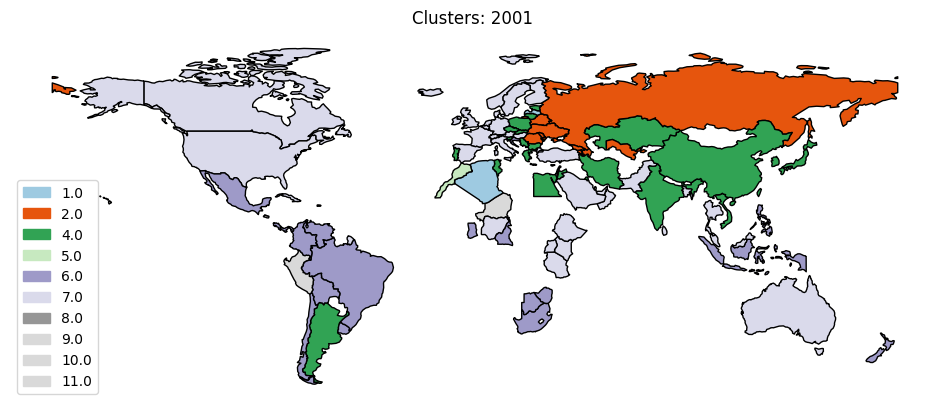

In [7]:
_, _ = uf.plot_map_discrete(df_map, "cluster", country_column="alpha-3", title=f"Clusters: {year}")

In [8]:
country_labels = df_map.sort_values(["cluster", "total_articles"], ascending=[True, False])["alpha-2"].to_list()

uf.plotly_heatmap(
    df_example.loc[country_labels, country_labels],
    x_labels=country_labels,
    y_labels=country_labels,
    z_min=0, z_max=0.5,
    title=f"Distance between countries, {year}",
    x_type="country", y_type="country"
)

# Yearly analysis

In [633]:
# get raw mapping

start_year = 1970
end_year = 2023

subfield_tree = uf.get_subfield_tree(uf.df_topics)

df_map_yearly_list = []
medoid_list = []

cutoff = 500

# switch_years = {1998: 3}

silhouette_list = []
medoid_silhouette_list = []

for year_loop in range(start_year, end_year+1):
    country_idx = df_cutoff.xs(year_loop, level=1).query(f"total >= @cutoff").index.to_list()
    # df_cs = df_cs_yearly.xs(year, level=1).loc[country_idx]
    # country_idx = df_cs_roll_yearly.xs(year_loop, level=1).sum(axis=1).to_frame("total").query("total >= @cap_articles").index.to_list()
    
    df_dist_loop = (
        df_dist_yearly
        .xs(year_loop, level=1)
        .loc[country_idx, country_idx]
    )
    df_dist_loop = df_dist_loop.loc[df_dist_loop.index, df_dist_loop.index]
    D_loop = df_dist_loop.loc[df_dist_loop.index, df_dist_loop.index].fillna(0).values
    
    if df_dist_loop.empty:
        continue
    # param_value = switch_years.get(year_loop, param_value)
    
    condensed_D = squareform(D_loop)

    param_value = 0.2
    method = "average"
    param = "distance"

    Z = linkage(condensed_D, method=method, optimal_ordering=True)
    labels = fcluster(Z, t=param_value, criterion=param)

    silhouette_list.append(silhouette_score(D_loop, labels, metric="precomputed"))

    df_map_yearly_list.append((
        pd.DataFrame(labels, index=df_dist_loop.index, columns=["cluster"])
        .assign(year=year_loop)
        .reset_index(names="country")
    ))

df_map_yearly = pd.concat(df_map_yearly_list)

# df_map_yearly.to_csv(uf.PATH+f"df_map_{param_value}_linkage_yearly_short_w1_{mode}.csv", index=False)

In [634]:
df_map_yearly

,country,cluster,year
0,AR,2,1974
1,AT,4,1974
2,AU,4,1974
3,BE,4,1974
4,BG,5,1974
...,...,...,...
138,VN,2,2023
139,YE,3,2023
140,ZA,1,2023
141,ZM,1,2023


In [635]:
df_cs_yearly

1100  1102  1103  1104  1105  1106  1107  1108  1109   1110  \
country year                                                                
AD      1985   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN   
        1991   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN   
        1993   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN   
        1996   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN   
        1997   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN   
...            ...   ...   ...   ...   ...   ...   ...   ...   ...    ...   
ZW      2019  23.0  16.0  15.0   NaN  32.0  32.0   NaN   NaN   NaN   76.0   
        2020  23.0  19.0  19.0   NaN  29.0  27.0   NaN   NaN   NaN   80.0   
        2021  29.0  25.0  19.0   NaN  35.0  23.0   NaN   NaN   NaN   92.0   
        2022  33.0  27.0  20.0   NaN  40.0  30.0   NaN   NaN   NaN  101.0   
        2023  40.0  27.0  17.0   NaN  42.0  44.0  19.0   NaN  20.0  102.0   

              ...  3604  3605  3607  3608  3609  3611  3612  3614  3616  3002  
country year  ...                                                              
AD      1985  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
        1991  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
        1993  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
        1996  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
        1997  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
...           ...   ...   ...   ...   ...   ...   ...   ...   ...   ...   ...  
ZW      2019  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
        2020  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
        2021  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
        2022  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
        2023  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  

[10461 rows x 252 columns]

In [636]:
df_map_yearly_full = (
    df_map_yearly
    .merge(df_cs_yearly.sum(axis=1).to_frame("total_articles"), left_on=["country", "year"], right_index=True)
)

In [637]:
df_map_yearly.groupby(["year", "cluster"], as_index=False).agg(list)


,year,cluster,country
0,1974,1,"[DK, FI, SE]"
1,1974,2,"[AR, BR, MX, NG]"
2,1974,3,"[HR, PL]"
3,1974,4,"[AT, AU, BE, CA, CH, CN, CZ, DE, EG, FR, GB, G..."
4,1974,5,"[BG, RU, UA]"
...,...,...,...
341,2023,2,"[AE, BY, CN, CZ, DZ, IN, IQ, MM, RU, SK, VN]"
342,2023,3,"[AT, AU, BD, BE, BG, CA, CD, CH, CM, DE, DK, E..."
343,2023,4,"[EG, SY, TN]"
344,2023,5,"[BF, BJ, CI]"


In [1099]:
def jaccard_similarity(a, b):
    a, b = set(a), set(b)
    return len(a & b) / len(a | b)

def find_dynamic_communities(df_map_yearly: pd.DataFrame):
    df_map_list = df_map_yearly.groupby(["year", "cluster"], as_index=False).country.agg(list)
    years_list = df_map_list.year.drop_duplicates().sort_values().to_list()

    threshold = 0.8
    share_articles = 0.01

    initial_communities = df_map_list.query(f"year == {years_list[0]}").country.to_list()
    dyn_communities = dict(zip(range(1, len(initial_communities)+1), initial_communities))

    dyn_community_idx = len(initial_communities) + 1
    print(dyn_communities.keys(), dyn_community_idx)
    match_list = []

    for year_loop in years_list[1:]:
        year_communities = df_map_list.query("year == @year_loop").country.to_list()
        year_comm_number = df_map_list.query("year == @year_loop").cluster.to_list()
        for i, comm in enumerate(year_communities):
            comm_articles = df_map_yearly.query(f"year == @year_loop and country in @comm").total_articles.sum() / df_map_yearly.query(f"year == @year_loop").total_articles.sum()

            if comm_articles <= share_articles:
                match_list.append({"year": year_loop, "cluster": year_comm_number[i], "dyn_comm": 0, "n_countries": len(comm), "n_articles": comm_articles, "dyn_comm_str": str(0)})
                continue

            dyn_match = -1
            dyn_sim = 0
            for dyn_idx, dyn in dyn_communities.items():
                sim = jaccard_similarity(comm, dyn)
                if (sim >= threshold) and (sim >= dyn_sim):
                    dyn_match = dyn_idx
                    dyn_sim = sim
            if dyn_match == -1:
                dyn_communities[dyn_community_idx] = comm
                match_list.append({"year": year_loop, "cluster": year_comm_number[i], "dyn_comm": dyn_community_idx, "n_countries": len(comm), "n_articles": comm_articles, "dyn_comm_str": str(dyn_community_idx)})
                dyn_community_idx += 1
            else:
                dyn_communities[dyn_match] = comm
                match_list.append({"year": year_loop, "cluster": year_comm_number[i], "dyn_comm": dyn_match, "n_countries": len(comm), "n_articles": comm_articles, "dyn_comm_str": str(dyn_match)})
    return match_list

In [1100]:
df_dyn_mapping = pd.json_normalize(find_dynamic_communities(df_map_yearly_full))

# noise_dyn_comm = df_dyn_mapping.groupby("dyn_comm").year.count().to_frame("n_years").query("n_years == 1").index.to_list()
# df_dyn_mapping.loc[df_dyn_mapping["dyn_comm"].isin(noise_dyn_comm), "dyn_comm"] = 0
# df_dyn_mapping.loc[df_dyn_mapping["dyn_comm"].isin(noise_dyn_comm), "dyn_comm_str"] = "0"

dict_keys([1, 2, 3, 4, 5, 6]) 7


In [1101]:
df_dyn_mapping_yearly = (
    df_map_yearly_full
    .merge(df_dyn_mapping, left_on=["year", "cluster"], right_on=["year", "cluster"], how="left")
    .drop(columns="cluster")
    .rename(columns={"dyn_comm": "cluster"})
)

In [1102]:
# (
#     df_map_yearly_full
#     .merge(df_dyn_mapping, left_on=["year", "cluster"], right_on=["year", "cluster"], how="left")
#     # .drop(columns="cluster")
#     # .rename(columns={"dyn_comm": "cluster"})
#     .query("dyn_comm == 0")
#     .groupby(["year", "dyn_comm"])
#     .agg(list)
#     # .head(10)
# )

In [1103]:
df_stats_cluster = uf.get_cluster_stats(df_map_yearly, df_cs_yearly.reset_index(), df_dist_yearly.reset_index())

share_articles = 0.01
df_undefined_agg_yearly = (
    df_stats_cluster
    .query("total_articles_share < @share_articles")
    [["year", "cluster"]]
    .groupby("year", as_index=False)
    .agg(list)
)

df_map_agg_yearly_list = []
for (year_loop, cluster_list) in df_undefined_agg_yearly.values:
    cluster_dict = dict(zip(cluster_list, [-1]*len(cluster_list)))
    df_map_agg_yearly_list.append(df_map_yearly.query("year == @year_loop").replace({"cluster": cluster_dict}))
df_map_agg_yearly = pd.concat(df_map_agg_yearly_list)

In [1104]:
importlib.reload(uf)

<module 'utility_functions' from '/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py'>

In [1105]:
# clean clusters for all years

fixed_country_list = ["US", "CN", "RU", "ID"]

df_map_clean_yearly_list = []
df_map_prev = df_map_agg_yearly.query("year == @start_year").drop(columns=["year"]).set_index("country")
for year_loop in range(start_year+1, end_year+1):
    
    df_map_cur = df_map_agg_yearly.query("year == @year_loop").drop(columns=["year"]).set_index("country")
    # display(df_map_cur)
    # display(df_map_prev)

    df_map_cur_clean, df_medoids_cur_clean = uf.clean_clusters(df_map_cur, df_map_prev, fixed_country_list=[])
    df_map_clean_yearly_list.append(df_map_cur_clean.assign(year=year_loop).reset_index(names="country"))
    df_map_prev = df_map_cur_clean
df_map_clean_yearly = pd.concat(df_map_clean_yearly_list)

# df_map_clean_yearly.to_csv(uf.PATH+f"df_map_{param_value}_linkage_short_clean_yearly_w1_{mode}.csv", index=False)

In [1106]:
df_map_analysis = df_dyn_mapping_yearly[["year", "country", "cluster"]]

In [1107]:
df_stats_cluster = uf.get_cluster_stats(df_map_analysis, df_cs_yearly.reset_index(), df_dist_yearly.reset_index())

In [1108]:
df_cluster_prob_yearly_list = []

for year_loop in range(start_year, end_year+1):
    df_cs_loop = df_cs_yearly.xs(year, level=1)
    df_cluster_prob = uf.get_cluster_probabilities(df_map_analysis.query("year==@year_loop"), df_cs_loop)
    df_cluster_prob_yearly_list.append(df_cluster_prob.assign(year=year_loop).reset_index(names="cluster"))
df_cluster_prob_yearly = pd.concat(df_cluster_prob_yearly_list)
# df_cluster_prob_yearly.to_csv(uf.PATH+f"df_prob_{param_value}_medoid_short_yearly_w1_{mode}.csv", index=False)

In [1109]:
pivot = df_map_analysis.pivot(index="country", columns="year", values="cluster")
pivot

clusters = pivot.values

# Broadcasting comparison
same_cluster = clusters[:, None, :] == clusters[None, :, :]

# Count matches across years
co_membership = same_cluster.sum(axis=2)

# Convert back to dataframe
df_dist_clusters_yearly = 1 - pd.DataFrame(
    co_membership,
    index=pivot.index,
    columns=pivot.index
) / (end_year - start_year)

df_n_years = pd.DataFrame(
    co_membership,
    index=pivot.index,
    columns=pivot.index
)
df_dist_clusters_yearly = 1 - df_n_years.div(np.diagonal(df_n_years.values))

# df_dist_clusters_yearly.to_csv(uf.PATH+f"df_dist_countries_{param_value}_medoid_short_w1_{mode}.csv", index=True)

In [1110]:
year = 2022

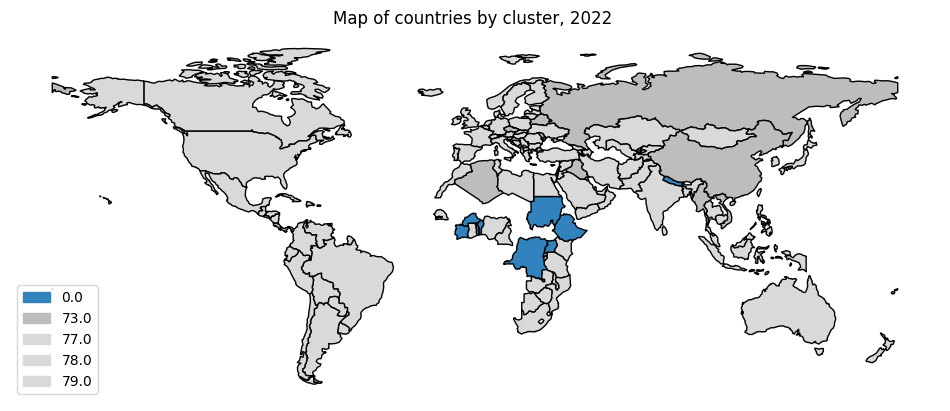

In [1111]:
clusters_tmp = list(df_map_analysis.query("year == @year").cluster.sort_values().drop_duplicates().astype(int))
# print(clusters_tmp)
# labels = [df_legend.loc[(year, cluster), "leader"].values[0] for cluster in clusters_tmp]
# for cluster in clusters_tmp:
#     if cluster < len(fixed_country_list):
#         if fixed_country_list[cluster] in df_map_clean_yearly.query("year == @year and cluster == @cluster").country:
#             labels.append(fixed_country_list[cluster])
#         else:
#             labels.append(df_cs_yearly
#                 .xs(year, level=1)
#                 .merge(df_map_clean_yearly.query("year == @year and cluster == @cluster"), left_index=True, right_on="country", how="right")
#                 .set_index("country")
#                 .drop(columns=["cluster", "year"])
#                 .sum(axis=1)
#                 .sort_values(ascending=False)
#                 .index[0])

#     else:
#         labels.append(df_cs_yearly
#                 .xs(year, level=1)
#                 .merge(df_map_clean_yearly_test.query("year == @year and cluster == @cluster"), left_index=True, right_on="country", how="right")
#                 .set_index("country")
#                 .drop(columns=["cluster", "year"])
#                 .sum(axis=1)
#                 .sort_values(ascending=False)
#                 .index[0])

max_n_clusters = df_map_analysis.cluster.nunique()
_, _ = uf.plot_map_discrete(
    df_map_analysis.sort_values("cluster").query("year==@year").merge(uf.df_country[["alpha-2", "alpha-3"]], left_on="country", right_on="alpha-2"),
    "cluster",
    title=f"Map of countries by cluster, {year}",
    max_values=max_n_clusters, 
    # labels=labels
)

In [1112]:
country_labels = (
    df_map_analysis.query("year==@year")
    .merge(df_cs_yearly.xs(year, level=1).sum(axis=1).to_frame("total"),
           left_on="country", right_index=True, how="left")
    .sort_values(["cluster", "total"], ascending=[True, False])["country"].to_list()
)
# param_value = 0.2
# y_labels = df_cs.sum(axis=1).sort_values(ascending=False).index.to_list()
# y_labels = df_dist.index.to_list()
uf.plotly_heatmap(
    df_dist_yearly.xs(year, level=1).loc[country_labels, country_labels],
    x_labels=country_labels,
    y_labels=country_labels,
    z_min=0, z_max=param_value*2,
    # colorscale="symmetrical",
    x_type="country",
    y_type="country",
    title=f"Distance between countries, {year}",
    line_height=10
)

In [1113]:
subfield_list = df_cs_yearly.columns.to_list()
df_cluster_prob_yearly = (
    df_cs_yearly
    .fillna(0)
    .merge(df_map_analysis.set_index(["country", "year"]), left_index=True, right_index=True, how="right")
    .reset_index()
    .drop("country", axis=1)
    .groupby(["cluster", "year"])
    [subfield_list]
    .sum()
)
df_cluster_prob_yearly = df_cluster_prob_yearly.div(df_cluster_prob_yearly.sum(axis=1), axis=0)

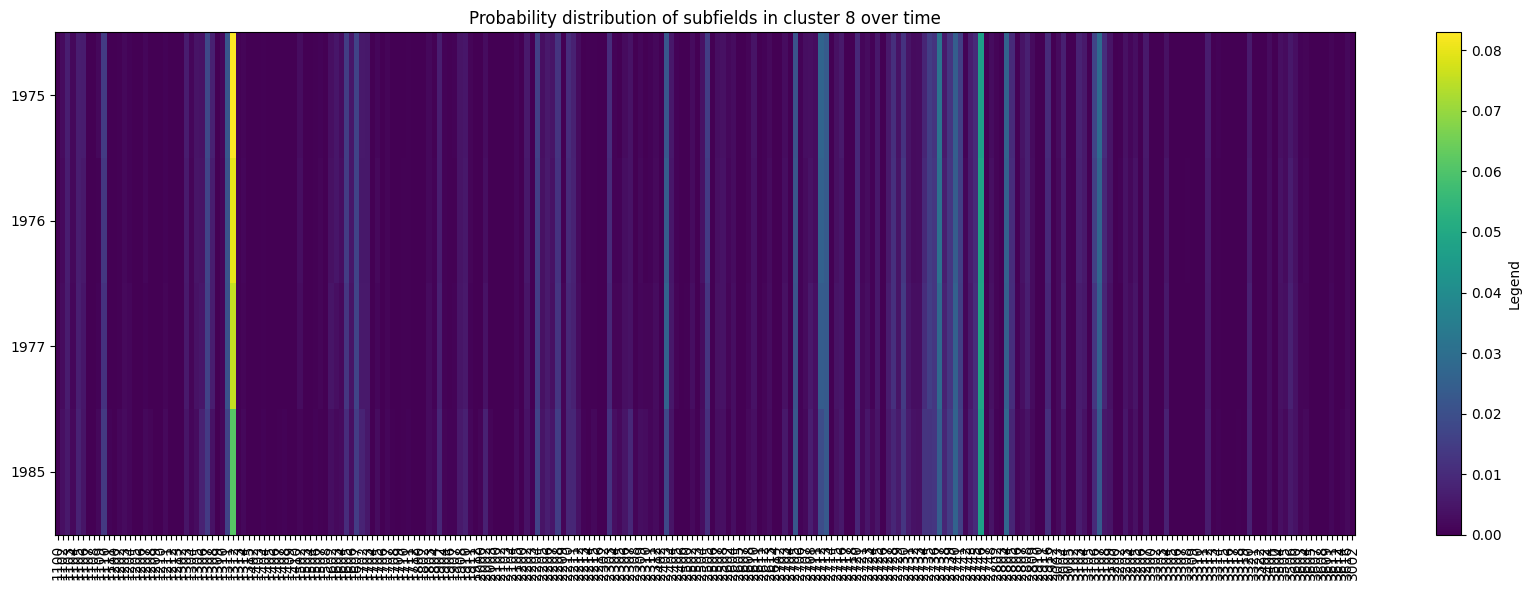

In [1114]:
cluster1 = 8

df = df_cluster_prob_yearly.xs(cluster1, level=0)

uf.plot_heatmap(
    df, x_labels=df.columns, y_labels=df.index,
    title=f"Probability distribution of subfields in cluster {cluster1} over time",
    # z_min=-0.02, z_max=0.02, line_height=10,
    # x_type="subfield"
)

In [1115]:
# cluster1 = 3
# cluster2 = 5

# df0 = df_cluster_prob_yearly.xs(cluster1, level=0)
# df1 = df_cluster_prob_yearly.xs(cluster2, level=0)

# df = df0.sub(df1)

# uf.plotly_heatmap(
#     df, x_labels=df.columns, y_labels=df.index,
#     title=f"Probability distribution of subfields in cluster {cluster1} minus cluster {cluster2} over time",
#     z_min=-0.02, z_max=0.02, line_height=10,
#     x_type="subfield"
# )

In [1116]:
import plotly.express as px

fig = px.area(
    df_stats_cluster,
    x="year",
    y="countries_share",
    color="cluster",
    title="Cluster share over time (articles)"
)

fig.update_layout(
    yaxis_range=[0, 1],
    xaxis_title="Year",
    yaxis_title="Share"
)

fig.show()

In [1117]:
import plotly.express as px

fig = px.area(
    df_stats_cluster,
    x="year",
    y="total_articles_share",
    color="cluster",
    title="Cluster share over time (articles)"
)

fig.update_layout(
    yaxis_range=[0, 1],
    xaxis_title="Year",
    yaxis_title="Share"
)

fig.show()

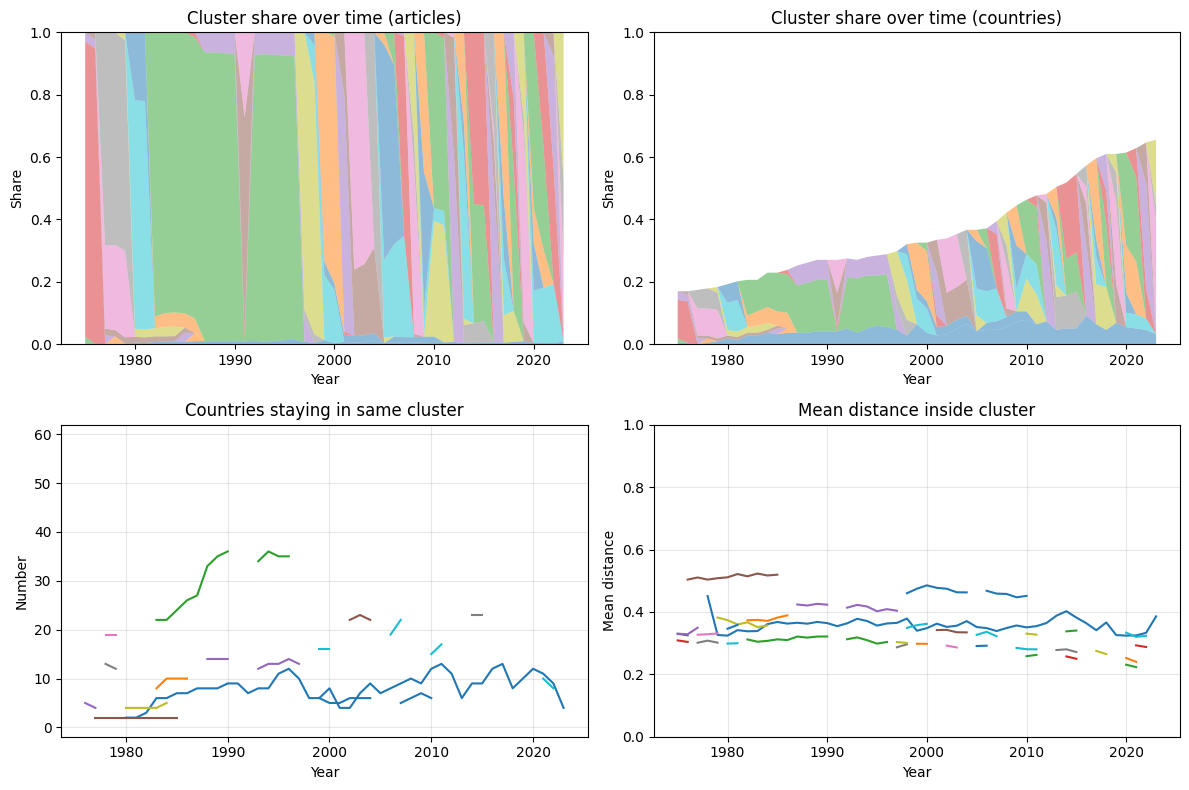

In [1118]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# ==============================
# 1️⃣ Articles share (stacked)
# ==============================
pivot = df_stats_cluster.pivot(
    index="year", columns="cluster", values="total_articles_share"
).fillna(0)

axes[0, 0].stackplot(
    pivot.index,
    *pivot.values.T,
    labels=[f"Cluster {i}" for i in pivot.columns],
    alpha=0.5
)

axes[0, 0].set_ylim(0, 1)
axes[0, 0].set_title("Cluster share over time (articles)")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("Share")
# axes[0, 0].legend()


# ==============================
# 2️⃣ Countries share (stacked)
# ==============================
pivot = df_stats_cluster.pivot(
    index="year", columns="cluster", values="countries_share"
).fillna(0)

axes[0, 1].stackplot(
    pivot.index,
    *pivot.values.T,
    labels=[f"Cluster {i}" for i in pivot.columns],
    alpha=0.5
)


axes[0, 1].set_ylim(0, 1)
axes[0, 1].set_title("Cluster share over time (countries)")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Share")
# axes[0, 1].legend()


# ==============================
# 3️⃣ Number stayed
# ==============================
pivot = df_stats_cluster.pivot(
    index="year", columns="cluster", values="n_stayed"
)

for cluster in pivot.columns:
    axes[1, 0].plot(pivot.index, pivot[cluster], label=f"Cluster {cluster}")

axes[1, 0].set_title("Countries staying in same cluster")
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("Number")
# axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)


# ==============================
# 4️⃣ Mean distance
# ==============================
pivot = df_stats_cluster.pivot(
    index="year", columns="cluster", values="mean_distance"
)

for cluster in pivot.columns:
    axes[1, 1].plot(pivot.index, pivot[cluster], label=f"Cluster {cluster}")
# axes[1, 1].plot(range(start_year+1, end_year+1), mean_global, label="Global")

axes[1, 1].set_title("Mean distance inside cluster")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("Mean distance")
axes[1, 1].set_ylim(0, 1)
# axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)


plt.tight_layout()
plt.show()

In [1119]:
year = 1990
clusters_tmp = list(df_map_analysis.query("year == @year").cluster.sort_values().drop_duplicates().astype(int))

max_n_clusters = int(df_map_analysis.cluster.max())

fig = px.choropleth(
    df_map_analysis.sort_values("cluster").query("year==@year").merge(uf.df_country[["alpha-2", "alpha-3"]], left_on="country", right_on="alpha-2").assign(cluster_str=lambda df: df.cluster.astype(str)),
    locations="alpha-3",
    color="cluster_str",
    locationmode="ISO-3",
    color_continuous_scale="Plasma",
    title="Clusters: "+str(year)
)
fig.update_layout(
    margin=dict(l=0, r=0, t=30, b=0)
)
fig.show()
# _, _ = uf.plot_map_discrete(
#     df_map_analysis.sort_values("cluster").query("year==@year").merge(uf.df_country[["alpha-2", "alpha-3"]], left_on="country", right_on="alpha-2"),
#     "cluster",
#     title=f"Map of countries by cluster, {year}",
#     max_values=max_n_clusters, 
#     # labels=labels
# )

In [1120]:
importlib.reload(uf)

<module 'utility_functions' from '/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py'>

In [1121]:
df_map_analysis.query("year == 2008 and cluster == 18").merge(df_map_analysis.query("year == 2007 and cluster == 15"), on="country", how="outer")

,year_x,country,cluster_x,year_y,cluster_y


In [1122]:
year_sort = 2022
y_label = df_dyn_mapping_yearly.query("year == @year_sort").sort_values(["cluster", "total_articles"], ascending=False).country.to_list()

df_plot = (
    df_map_analysis
    # .query("cluster == @cluster")
    .assign(cluster_str=lambda df: df.cluster.astype(str))
    .pivot(index="country", columns="year", values="cluster_str")

    # .replace({cluster: 1})
    # .fillna(0)
)
uf.plotly_heatmap(df_plot.loc[y_label], x_labels=df_plot.columns, y_labels=y_label, line_height=5, y_type="country")

In [1123]:
uf.get_country_info("VG")

,name,region,sub-region,code
242,Virgin Islands (British),Americas,Latin America and the Caribbean,VG


# Individual year analysis

In [1260]:
year = 2010

In [1261]:
df_map_year = df_map_analysis.query("year == @year").merge(uf.df_country[["alpha-2", "alpha-3"]], left_on="country", right_on="alpha-2", how="left")

In [1262]:
cmap = plt.get_cmap("Set2")

In [1282]:
cluster_list = df_map_year.cluster.drop_duplicates().to_list()
cluster_labels = dict(zip(cluster_list ,["Cluster "+str(cl) if cluster_list[cl-1] != 0 else "Undefined" for cl in range(1, len(cluster_list)+1)]))
cluster_colors = dict(zip(cluster_list, cmap(np.linspace(0, 1, len(cluster_labels)))))

In [1283]:
import geopandas as gpd
import matplotlib.patches as mpatches

url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
world = gpd.read_file(url)
world = world.merge(df_map_year, left_on="ISO_A3", right_on="alpha-3", how="left")

world["color"] = world["cluster"].map(cluster_colors)
world["color"] = world["color"].fillna("white")

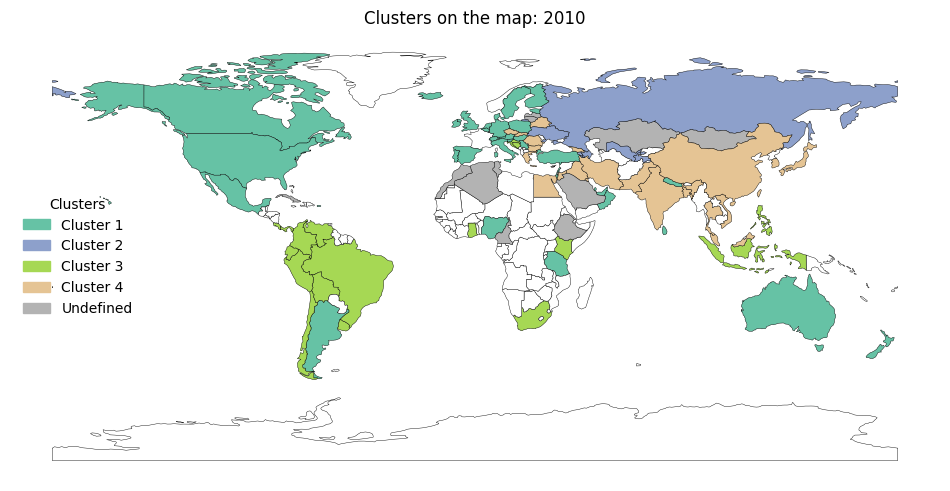

In [1284]:
fig, ax = plt.subplots(figsize=(12,6))

world.plot(
    color=world["color"],
    edgecolor="black",
    linewidth=0.3,
    ax=ax
)
# create legend
handles = [
    mpatches.Patch(color=cluster_colors[c], label=cluster_labels[c])
    for c in cluster_colors
]

ax.legend(
    handles=handles,
    title="Clusters",
    loc="center left",
    frameon=False
)
ax.set_axis_off()
ax.set_title(f"Clusters on the map: {year}")
plt.show()

In [1285]:
cluster_gini_countries = {}

for cluster in cluster_list:
    country_list = df_map_year.query("cluster == @cluster").country.to_list()
    cluster_gini_countries[cluster] = uf.gini(df_cs_yearly.xs(year, level=1).loc[country_list].sum(axis=1))

In [1286]:
cluster_gini_countries

{46.0: 0.7685255131134983,
 24.0: 0.7530936235083845,
 43.0: 0.7483346176444865,
 42.0: 0.8390368603395337,
 0.0: 0.5139120862917965}

In [1287]:
cluster_mean_dist = {}

for cluster in cluster_list:
    country_list = df_map_year.query("cluster == @cluster").country.to_list()
    df_dist_tmp = df_dist_yearly.xs(year, level=1).loc[country_list, country_list]
    np.fill_diagonal(df_dist_tmp.values, np.nan)
    cluster_mean_dist[cluster] = np.nanmean(df_dist_tmp.values)

In [1288]:
country_counts = df_map_year.drop(columns="year").groupby("cluster").country.count().loc[cluster_list].values

articles_counts = (
    df_map_year
    .drop(columns="year")
    .merge(df_cs_yearly.xs(year, level=1).sum(axis=1).to_frame("total"), left_on="country", right_index=True, how="left")
    .groupby(["cluster"])
    .total
    .sum()
    .loc[cluster_list]
    .values
)

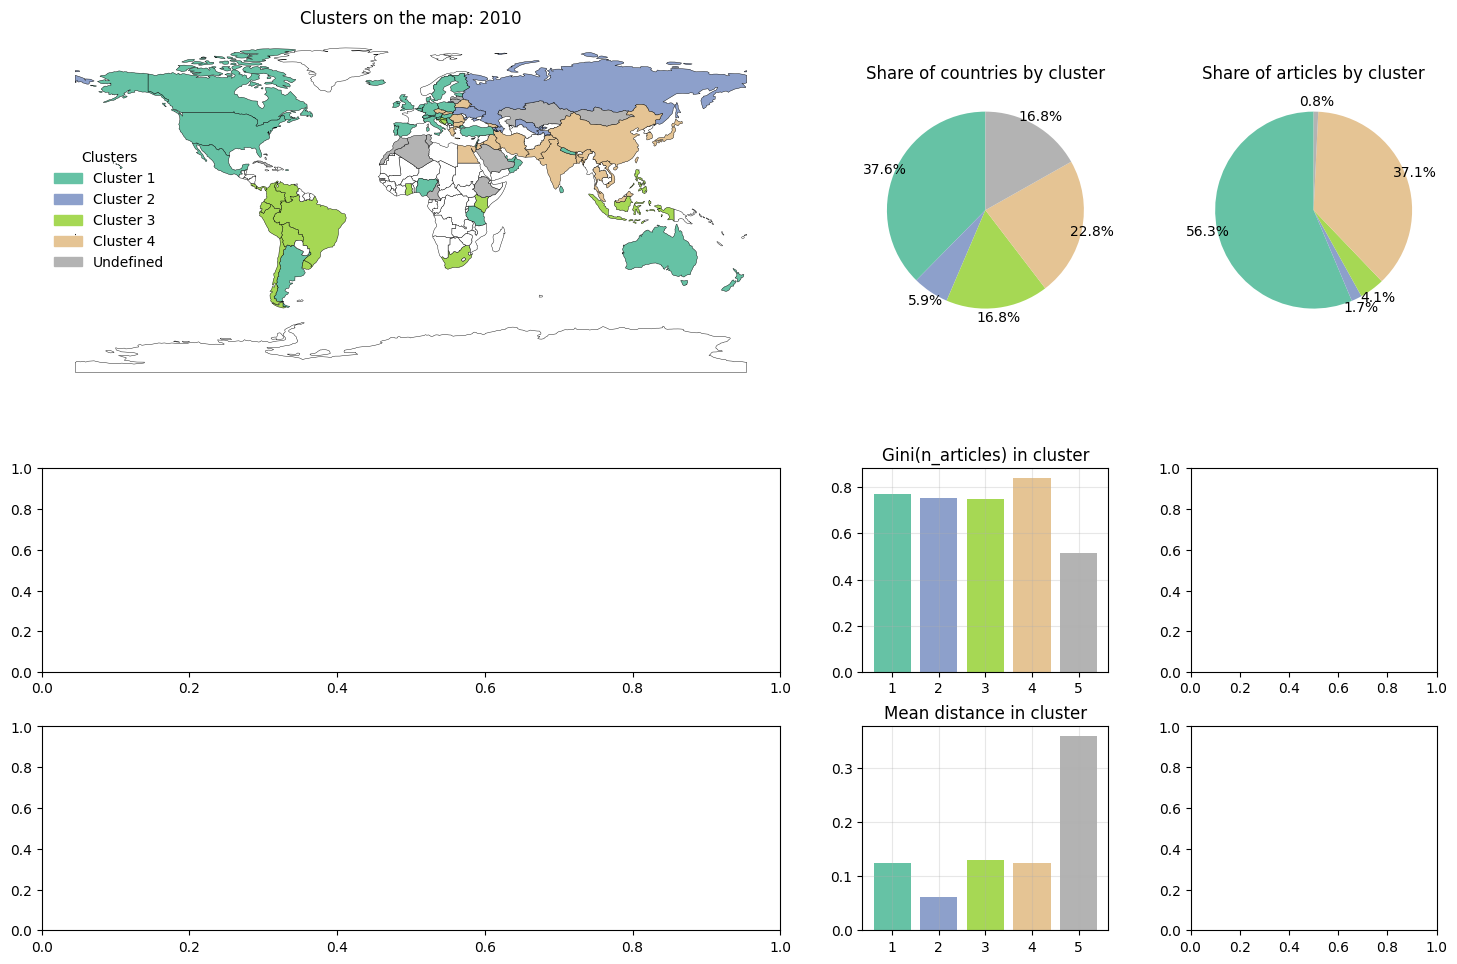

In [1289]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12), gridspec_kw={"width_ratios": [3, 1, 1], "height_ratios": [2, 1, 1]})

world.plot(
    color=world["color"],
    edgecolor="black",
    linewidth=0.3,
    ax=axes[0, 0]
)
# create legend
handles = [
    mpatches.Patch(color=cluster_colors[c], label=cluster_labels[c])
    for c in cluster_colors
]

axes[0, 0].legend(
    handles=handles,
    title="Clusters",
    loc="center left",
    frameon=False
)
axes[0, 0].set_axis_off()
_ = axes[0, 0].set_title(f"Clusters on the map: {year}")


axes[0, 1].pie(
    country_counts,
    # labels=cluster_labels.values(),
    colors=cluster_colors.values(),
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=1.1
)

axes[0, 1].set_title("Share of countries by cluster")

axes[0, 2].pie(
    articles_counts,
    # labels=cluster_labels.values(),
    colors=cluster_colors.values(),
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=1.1
)

axes[0, 2].set_title("Share of articles by cluster")

axes[1, 1].bar(
    range(1, len(cluster_list)+1),
    cluster_gini_countries.values(),
    color=cluster_colors.values()
)

axes[1, 1].set_xticks(range(1, len(cluster_list)+1))
axes[1, 1].set_title("Gini(n_articles) in cluster")
axes[1, 1].grid(alpha=0.3)

axes[2, 1].bar(
    range(1, len(cluster_list)+1),
    cluster_mean_dist.values(),
    color=cluster_colors.values()
)

axes[2, 1].set_xticks(range(1, len(cluster_list)+1))
axes[2, 1].set_title("Mean distance in cluster")
axes[2, 1].grid(alpha=0.3)
# axes[2, 1].set_xticklabels(cluster_labels.values())

# temporal clustering

In [727]:
start_year_plot = 2013
end_year_plot = 2023

pivot = df_map_yearly.query("(year >= @start_year_plot) and (year < @end_year_plot)").pivot(index="country", columns="year", values="cluster")
pivot

clusters = pivot.values

# Broadcasting comparison
same_cluster = clusters[:, None, :] == clusters[None, :, :]

# Count matches across years
co_membership = same_cluster.sum(axis=2)

# Convert back to dataframe
df_dist_clusters_yearly = 1 - pd.DataFrame(
    co_membership,
    index=pivot.index,
    columns=pivot.index
) / (end_year - start_year)

df_n_years = pd.DataFrame(
    co_membership,
    index=pivot.index,
    columns=pivot.index
)
df_dist_clusters_yearly = 1 - df_n_years.div(np.diagonal(df_n_years.values))

In [728]:
D = df_dist_clusters_yearly.fillna(0).values
D_sym = D.copy()
D_sym = np.triu(D_sym) + np.triu(D_sym, 1).T
# D_sym = np.tril(D_sym) + np.tril(D_sym, -1).T
np.fill_diagonal(D_sym, 0)
condensed_D = squareform(D_sym)

param_value = 0.7
method = "average"
param = "distance"
np.random.seed(0)

Z = linkage(condensed_D, method=method)
labels = fcluster(Z, t=param_value, criterion=param)

df_map_clusters = (
    pd.DataFrame(labels, index=df_dist_clusters_yearly.index, columns=["cluster"])
    .merge(uf.df_country[["alpha-2", "alpha-3"]], left_index=True, right_on="alpha-2")
    .merge(df_cs_example.sum(axis=1).to_frame("total_articles"), left_on="alpha-2", right_index=True)
    .assign(cluster_str=lambda df: df.cluster.astype(str))
)

print("Clusters: ")
print(pd.Series(labels).value_counts())
print()

print("Silhouette Score: ", silhouette_score(D, labels, metric="precomputed"))
# print("Dunn Index: ", uf.dunn_index(df_example, labels))

Clusters: 
9     56
5     39
3     16
4     14
8      5
1      5
2      3
7      1
6      1
10     1
11     1
Name: count, dtype: int64

Silhouette Score:  0.25538333656036233


In [729]:
# import plotly.express as px

fig = px.choropleth(
    df_map_clusters,
    locations="alpha-3",
    color="cluster_str",
    locationmode="ISO-3",
    color_continuous_scale="Viridis",
    title=f"From {start_year_plot} to {end_year_plot}"
)
fig.update_layout(
    margin=dict(l=0, r=0, t=30, b=0)
)
fig.show()

In [730]:
year = 2023
# y_labels = df_cs.sum(axis=1).sort_values(ascending=False).index.to_list()
y_labels = (
    df_map_clusters
    # .query("year == @year")
    # .merge(df_cs_yearly.xs(year, level=1).sum(axis=1).to_frame(name="total_articles").reset_index(), left_on="alpha-2", right_index="country", how="left")
    .sort_values(["cluster", "total_articles"], ascending=[True, False])
    ["alpha-2"]
    .to_list()
)

uf.plotly_heatmap(
    df_dist_clusters_yearly.loc[y_labels, y_labels],
    # (df_dist_clusters_yearly.loc[y_labels, y_labels] < 0.2).astype(int),
    x_labels=y_labels,
    y_labels=y_labels,
    title=f"Cluster co-membership over years (share years in different clusters) - {year}",
    colorscale="non-symmetrical",
    x_type="country",
    y_type="country",
    line_height=10
)